In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import OrdinalEncoder,LabelEncoder

In [17]:
data = pd.read_csv('PlayTennis.csv')
outlook_encoder = OrdinalEncoder()
data['Outlook'] = outlook_encoder.fit_transform(data[['Outlook']])
le = LabelEncoder()
for col in data.columns:
    data[col] = le.fit_transform(data[col])
data
play_encoder = OrdinalEncoder()
data['play'] = play_encoder.fit_transform(data[['Play Tennis']])

In [18]:
x = data.drop('Play Tennis', axis=1)
y = data['Play Tennis']

In [19]:
clf_gini = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf_gini.fit(x, y)
y_pred_gini = clf_gini.predict(x)


In [20]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [21]:
print("Accuracy:", accuracy_score(y, y_pred_gini))


Accuracy: 1.0


In [22]:
print("classification report:\n", classification_report(y, y_pred_gini))

print("confusion matrix:\n", confusion_matrix(y, y_pred_gini))

classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         9

    accuracy                           1.00        14
   macro avg       1.00      1.00      1.00        14
weighted avg       1.00      1.00      1.00        14

confusion matrix:
 [[5 0]
 [0 9]]


[Text(0.5, 0.75, 'play <= 0.5\nentropy = 0.94\nsamples = 14\nvalue = [5, 9]\nclass = Yes'),
 Text(0.25, 0.25, 'entropy = 0.0\nsamples = 5\nvalue = [5, 0]\nclass = No'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'entropy = 0.0\nsamples = 9\nvalue = [0, 9]\nclass = Yes'),
 Text(0.625, 0.5, '  False')]

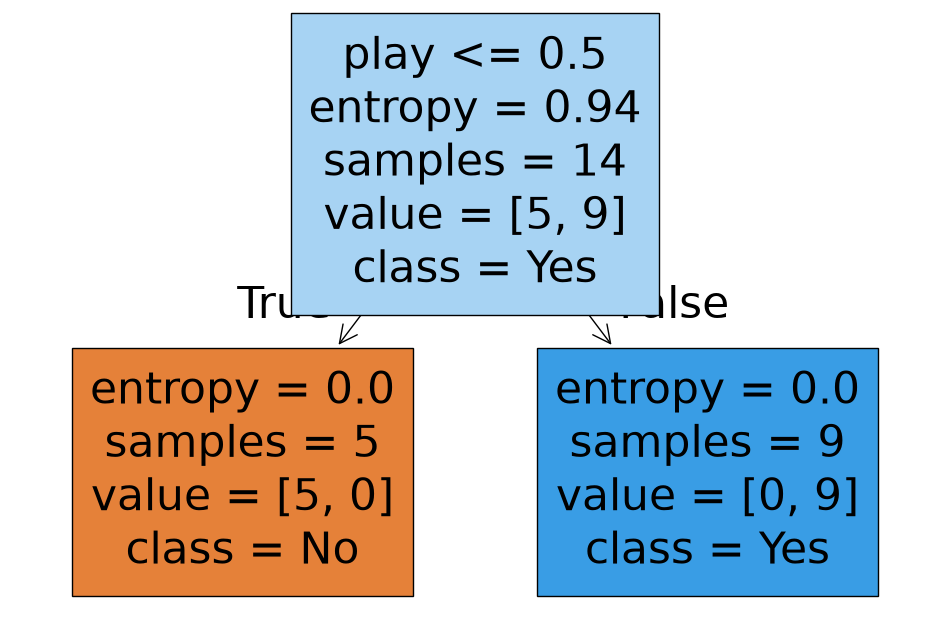

In [23]:
from sklearn import tree
plt.figure(figsize=(12,8))
tree.plot_tree(clf_gini, filled=True, feature_names=x.columns, class_names=['No', 'Yes'])